# **CODA (v2.0.0) Tutorial 3 — 3D Reconstruction**

> **Goal of Tutorial 3**: Reconstruct a coherent 3D tissue volume from consecutive spatial transcriptomics sections.

## **Environment setup & imports**

In [1]:
from CODA.Alignment import *
from CODA.Preprocessing import *
from CODA.RGBgenerator import *
from CODA.utils import *
from CODA.Cross_correlation import *
from CODA.Common_domain import *

D:\Anaconda\envs\CODA_test\lib\site-packages\louvain\__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


* You can download the data required for this tutorial here: [Example data 3](<https://drive.google.com/drive/folders/1U4p6eqoN6SycbO4jDP6v3-tG9d9oWCw0?usp=drive_link>).

* After downloading, place the files in the same directory as this notebook (`Tutorial 3 (3D reconstruction).ipynb`).

In [2]:
adata = sc.read('STARmap.h5ad')

### Optional: make clean, ordered slice labels

This step converts a numeric `obs['slice']` (sometimes noisy/decimal) into **ordered categorical labels** (`slice1`, `slice2`, …) by rounding to a chosen precision and mapping unique values to names. It helps with **plot ordering, legend consistency, and grouping** in 3D reconstruction.
- **When it’s useful**: your dataset only has a numeric slice index or slightly noisy z-values that need clean grouping.
- **When you can skip**: your data already has discrete IDs (e.g., `obs['slice_label']`/`section_id`) **or** you have exact z-spacing metadata for stacking.

In [3]:
import numpy as np, pandas as pd
import scanpy as sc, matplotlib.pyplot as plt, matplotlib as mpl
from matplotlib.patches import Patch

decimals = 0         
z = np.asarray(adata.obs['slice'], float)
z_rounded = np.round(z, decimals=decimals)

uniq = np.sort(np.unique(z_rounded[~np.isnan(z_rounded)]))
labels = {v: f"slice{i+1}" for i, v in enumerate(uniq)}
slice_cat = pd.Categorical(
    [labels.get(v, "NA") for v in z_rounded],
    categories=[f"slice{i+1}" for i in range(len(uniq))],
    ordered=True
)

adata.obs['slice_label'] = slice_cat

### Per-slice centering of 2D coordinates (optional)

For each slice (given by `obs['slice_label']`), we subtract the slice-wise mean (or median) from 2D coordinates in `obsm['spatial']`, and stores the result in `obsm['spatial_centered']`.

**Notes**  
- Use as a visualization aid or for normalized overlays; not required for 3D reconstruction.  
- `sc.pl.embedding(..., basis="spatial_centered")` will plot the centered coordinates.  

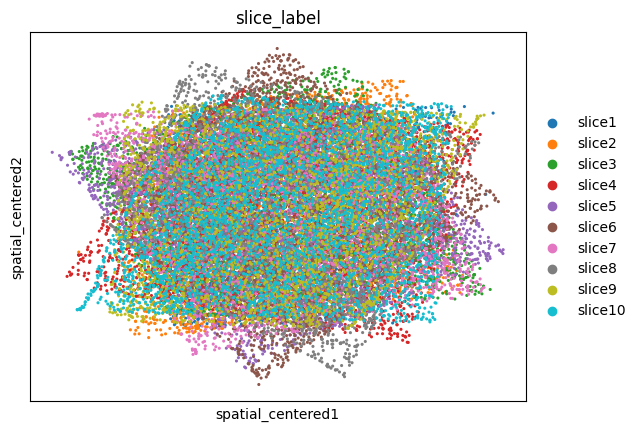

In [4]:
def center_by_slice(
    adata,
    spatial_key: str = "spatial",
    slice_key: str = "slice_label",
    out_key: str = "spatial_centered",
    use_median: bool = False,
):

    X = np.asarray(adata.obsm[spatial_key], dtype=float)
    if X.ndim != 2 or X.shape[1] != 2:
        raise ValueError(f"adata.obsm['{spatial_key}'] must be a (n_cells, 2) array. Got shape {X.shape}")

    labels = adata.obs[slice_key].astype(str).values
    Xc = X.copy()

    for g in np.unique(labels):
        mask = (labels == g)
        if not np.any(mask):
            continue
        center = np.median(X[mask], axis=0) if use_median else np.mean(X[mask], axis=0)
        Xc[mask] = X[mask] - center

    adata.obsm[out_key] = Xc
    return out_key

new_basis = center_by_slice(adata, spatial_key="spatial", slice_key="slice_label", out_key="spatial_centered")
sc.pl.embedding(adata, basis="spatial_centered", color="slice_label", show=True, s=20)

### Get the slice IDs

In [5]:
slice_ids = adata.obs['slice_id'].astype(str)
sids = slice_ids.unique().tolist()
adatas = [adata[slice_ids == sid].copy() for sid in sids] 

### Prep for 3D alignment — slice selection & ordering

- We subset the dataset to the **target slices** (`adata_sel`) and enforce `obs['slice_id']` as **string** to ensure exact matching.
- We then build an **ordered list** of per-slice AnnData objects (`adata_list`) following the sequence in `slices`.  
  This order defines the **stacking / z-order** and the iteration order for alignment.
- **Auto-detected IDs**: if `slices` was obtained via  
  `slice_ids = adata.obs['slice_id'].astype(str)` → `sids = slice_ids.unique().tolist()`, the order is **auto-detected** and may not match your desired anatomical order.  
  **Manually adjust** `slices` if needed (e.g., ascending by z, or a custom list).
- The assertion ensures all requested slice IDs exist; if it fails, check for typos or missing slices.


In [6]:
# Manually adjust slices if needed
slices = sids

In [7]:
adata_sel = adata[adata.obs['slice_id'].astype(str).isin(slices)].copy()
adata_sel.obs['slice_id'] = adata_sel.obs['slice_id'].astype(str)

adata_list = [adata_sel[adata_sel.obs['slice_id'] == sid].copy() for sid in slices]
assert len(adata_list) == len(slices), "Some slices are not present in the data. Please check the slices list."

### Chain alignment for 3D reconstruction

- **Labels for alignment**: we use `cell_types` as the label set (`if_labeled=True, label_key="cell_types"`), so correspondences are constrained by cell-type annotations. You can swap in any other label column if desired.
- **Mode choice**: use **`mode="G1"` (rigid)** for serial-section 3D reconstruction to **preserve the original scale and distances** across slices. (G2/G2+ allow scale/shear and can distort the z-stack.)
- **Coordinates**: per slice, alignment uses `xy_keys=["spatial"]` for the input 2D coordinates.
- **Stacking**: after alignment, build 3D coordinates by appending a constant z for each slice (e.g., `z_step = 50.0`). Keep `z_step` consistent with your physical spacing if available.


In [8]:
xy_keys = ['spatial'] * len(adata_list)   
order   = list(range(len(adata_list)))   

aligned_list, params, start_id = align_stack_chain(
    adata_list, order=order, mode='G1', xy_keys=xy_keys,
    trim_fraction=0.10, lam=1e-2,
    if_labeled=True, label_key='cell_types', 
    min_shared_labels=1, verbose=True
)

z_step = 50.0  
for i, ad in enumerate(aligned_list):
    xy = ad.obsm['spatial_aligned']
    ad.obsm['spatial_3d'] = np.column_stack([xy, np.full((xy.shape[0],), i * z_step, dtype=xy.dtype)])

[0->1] label-based alignment on 'cell_types'
[1->2] label-based alignment on 'cell_types'
[2->3] label-based alignment on 'cell_types'
[3->4] label-based alignment on 'cell_types'
[4->5] label-based alignment on 'cell_types'
[5->6] label-based alignment on 'cell_types'
[6->7] label-based alignment on 'cell_types'
[7->8] label-based alignment on 'cell_types'
[8->9] label-based alignment on 'cell_types'


### Visualization

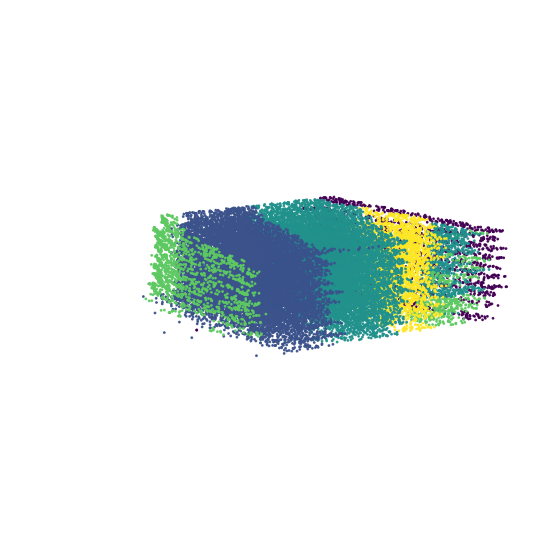

In [9]:
plot_3d_alignment_by_label(aligned_list, label_key='spatial_domain',
                           section_names=slices, point_size=1, elev=10, azim=50)